# Lab: Data exploration

---

<a id="learning-objectives"></a>
## Learning Objectives
*After completing this lab, you will be able to:*

- Explore and interrogate different data sets using our pandas and matplotlib.
- Interpret the findings to understand what the data tells us about the real world.

<a id="coffee"></a>

# <font color='blue'> Coffee shop data</font>

## Part A

In this Lab we'll be working with one datasets.
    
The dataset consists of coffee shop transactions, a dataset created by IBM and made available on [Kaggle](https://www.kaggle.com/datasets/ylchang/coffee-shop-sample-data-1113).

The data consists of coffee shop transactions in April 2019.

There are ~50,000 total transactions in the data set. The data consists of transactions from shops in New York City only.

Our task is to answer 3 questions:
1. **Which products offer the best margins?**
2. **Are particular customer groups spending more?**
3. **Which products generate the most sales?**

<br />

Let's start by reading in the data as a pandas `DataFrame` called `coffee_df`.

In [1]:
# Importing needed library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### 1.❓ Next, let's read in the data as a pandas `DataFrame` called `coffee_df`

In [2]:
coffee_df = pd.read_csv('./data/coffee_shop_lab.csv')

##### 2.❓Now preview the first 5 rows of the data.

In [5]:
coffee_df.head(5)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation
0,2019-04-01,12:04:43,558.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials
1,2019-04-01,11:15:38,22.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers
2,2019-04-01,12:05:31,659.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z
3,2019-04-01,16:49:38,407.0,1,2.5,2.5,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers
4,2019-04-01,19:17:34,537.0,2,5.0,2.5,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials


##### 3.❓ How many rows and columns does the dataset have?

In [27]:
coffee_df.shape
#49894 rows , 13 columns


(49894, 13)

##### 4.❓ Check the type of data in each column- do you notice any problems?

In [14]:
coffee_df.dtypes
#

transaction_date               str
transaction_time               str
customer_id                float64
quantity                     int64
line_item_amount           float64
unit_price                 float64
product_group                  str
product_category               str
product_type                   str
current_wholesale_price    float64
customer_since                 str
customer_birth_year        float64
customer_generation            str
dtype: object

> 👉 **Write Your Findings Here**: 
-- -#there is a problem on type of transaction_date it is string instead of dateaime
> #alsocustomer_since

##### 5.❓ You might have noticed earlier when running the `dtypes` command that the `transaction_date` and `customer_since` columns are currently being treated like strings. We need to convert them into date columns so we can calculate factors like how long someone's been a customer.

Try using pd.to_datetime() to convert these two columns to date representations

In [28]:
coffee_df['transaction_date'] = pd.to_datetime(coffee_df['transaction_date'])
coffee_df['customer_since'] = pd.to_datetime(coffee_df['customer_since'])

##### 6.❓ Examine the percentage of missing values in each column. What might these missing values represent? How would you suggest handling them?



In [33]:
missing = (coffee_df.isna().sum() / len(coffee_df))*100
missing


transaction_date            0.000000
transaction_time            0.000000
customer_id                50.172365
quantity                    0.000000
line_item_amount            0.000000
unit_price                  0.000000
product_group               0.000000
product_category            0.000000
product_type                0.000000
current_wholesale_price     0.000000
customer_since             50.190404
customer_birth_year        50.190404
customer_generation        50.190404
dtype: float64

👉 Since more than 50% of the customer-related data is missing

👉 The missing values in the customer-related columns of your coffee dataset could represent:

- Guest Customers 
- Incomplete Data Collection 
- Data Integration Issues
  

👉 Is the missing values essentials to your analysis? 
- If necessary:
    - consider finding the missing values
    - Or, create a dataset that contains the rows that have filled information and discard the rows that have null values for that customer-related columns.

- If not necessary in your analysis, just ignore them

##### 7.❓ Check for duplicate values, and remove them if any.

In [36]:
# how many duplicates we have
sum_duplicate = int(coffee_df.duplicated().sum())
sum_duplicate

149

In [42]:
# Remove the duplicates and check if the total duplicates is 0 now
cfe = coffee_df.copy()
cfe = cfe.drop_duplicates()

#for check
int(cfe.duplicated().sum())

0

##### 8.❓ Explore the unique values in all the categorical columns:
- product group
- product category
- product type
- customer_generation

1. What inconsistencies do you notice?
2. Is there a spelling consistency?
3. Do you need to fix anything?

In [46]:
# unique values in product group
cfe['product_group'].unique().tolist()


['Beverages', 'Food', 'Whole Bean/Teas', 'Add-ons', 'Merchandise']

In [47]:
# unique values in product category

cfe['product_category'].unique().tolist()

['Tea',
 'Coffee',
 'Drinking Chocolate',
 'Bakery',
 'Coffee beans',
 'Flavours',
 'Loose Tea',
 'Packaged Chocolate',
 'Branded']

In [50]:
# unique values in product type
cfe['product_type'].unique().tolist()


['Brewed Chai tea',
 'Organic brewed coffee',
 'Brewed Green tea',
 'Drip coffee',
 'Premium brewed coffee',
 'Gourmet brewed coffee',
 'Brewed Black tea',
 'Hot chocolate',
 'Barista Espresso',
 'Scone',
 'Brewed herbal tea',
 'Biscotti',
 'Pastry',
 'Organic Beans',
 'Regular syrup',
 'Herbal tea',
 'Gourmet Beans',
 'Black tea',
 'Sugar free syrup',
 'House blend Beans',
 'Premium Beans',
 'Chai tea',
 'Organic Chocolate',
 'Drinking Chocolate',
 'Green beans',
 'Green tea',
 'Espresso Beans',
 'Housewares',
 'Clothing']

In [51]:
# unique values in customer_generation
cfe['customer_generation'].unique().tolist()


['Older Millennials',
 'Baby Boomers',
 'Gen Z',
 'Gen X',
 'Younger Millennials',
 nan]

##### 9.❓The `describe()` method is a handy way of accessing summary statistics for an entire `DataFrame` in one go. Try running it on your `DataFrame`:


In [53]:
cfe.describe()


,transaction_date,customer_id,quantity,line_item_amount,unit_price,current_wholesale_price,customer_since,customer_birth_year
count,49745,24801.000000,49745.000000,49745.000000,49745.000000,49745.000000,24792,24792.000000
mean,2019-04-15 01:25:20.257312,4582.647837,1.439481,4.687731,3.384018,1.354957,2018-02-21 06:10:48.209099,1978.248871
min,2019-04-01 00:00:00,1.000000,1.000000,0.000000,0.800000,0.040000,2017-01-03 00:00:00,1950.000000
25%,2019-04-08 00:00:00,584.000000,1.000000,3.000000,2.500000,0.600000,2017-08-05 00:00:00,1965.000000
50%,2019-04-15 00:00:00,5417.000000,1.000000,3.750000,3.000000,0.750000,2018-02-22 00:00:00,1981.000000
75%,2019-04-22 00:00:00,8099.000000,2.000000,6.000000,3.750000,1.950000,2018-09-16 00:00:00,1992.000000
max,2019-04-29 00:00:00,8501.000000,8.000000,360.000000,45.000000,36.000000,2019-04-09 00:00:00,2001.000000
std,NaN,3247.554091,0.543316,4.441833,2.686402,2.204466,NaN,15.088333


##### 10.❓What is your findings about the above summery statistics?

> Write your findings here:

👉 The `line_item_amount` column has a minimum value of 0, which seems unusual. This could indicate potential error values.

👉 The quantity column appears to be right-skewed, with 75% of orders containing only two products, while the maximum quantity is 8.

- Let's start to clean up our dataset and answer the questions in our analysis.

- We have the total line item amount (the retail price) as well as the wholesale price of the product.

- We want to calculate the **total wholesale line item amount** so we can use it to calculate profit.

##### 11.❓Can you combine the existing wholesale amount and quantity columns to create a new column in the `DataFrame` called `total_wholesale_amount` which holds the new values?

In [56]:

cfe['total_wholesale_amount'] = cfe['current_wholesale_price'] * cfe['quantity']
cfe['total_wholesale_amount']

0        0.63
1        0.63
2        1.26
3        0.63
4        1.26
         ... 
49889    7.16
49890    7.16
49891    7.16
49892    7.16
49893    7.16
Name: total_wholesale_amount, Length: 49745, dtype: float64

##### 12.❓Can you now create a new column called `profit` which shows the difference between the wholesale price and retail price(line_item_amount)?

In [57]:
cfe['profit'] = cfe['line_item_amount'] - cfe['total_wholesale_amount']

##### 13.❓Find the highest sale price in the dataset.

In [74]:

float(cfe['line_item_amount'].max())


360.0

##### 14.❓Find the largest amount of profit.

In [66]:
float(cfe['profit'].max())


72.0

The largest profit is significant - but it's obviously not representative of how much profit is made on each transaction on average.

##### 15.❓Find the mean of all the profit.

In [75]:
float(cfe['profit'].mean())
cfe

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit
0,2019-04-01,12:04:43,558.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-06-19,1983.0,Older Millennials,0.63,1.87
1,2019-04-01,11:15:38,22.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-03-03,1953.0,Baby Boomers,0.63,1.87
2,2019-04-01,12:05:31,659.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2019-01-14,1996.0,Gen Z,1.26,3.74
3,2019-04-01,16:49:38,407.0,1,2.50,2.50,Beverages,Tea,Brewed Chai tea,0.63,2017-08-11,1963.0,Baby Boomers,0.63,1.87
4,2019-04-01,19:17:34,537.0,2,5.00,2.50,Beverages,Tea,Brewed Chai tea,0.63,2018-05-06,1980.0,Older Millennials,1.26,3.74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49889,2019-04-24,09:31:54,8113.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-01-08,1998.0,Gen Z,7.16,1.79
49890,2019-04-25,06:17:12,5778.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-04-08,1956.0,Baby Boomers,7.16,1.79
49891,2019-04-25,10:48:21,NaN,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,NaT,NaN,NaN,7.16,1.79
49892,2019-04-25,08:54:27,8039.0,1,8.95,8.95,Whole Bean/Teas,Loose Tea,Herbal tea,7.16,2017-06-26,1963.0,Baby Boomers,7.16,1.79


##### 16.❓Now, let's start filtering our data by writing logical tests. How many transactions were valued above the **mean** transaction amount?

In [80]:
int((cfe['line_item_amount'] > float(cfe['line_item_amount'].mean())).sum())


19544

##### 17.❓Create a new column called `profit_ratio` which shows the ratio between the wholesale and retail prices.

In [178]:
cfe['profit_ratio'] = cfe['total_wholesale_amount'] / cfe['line_item_amount']


##### 18.❓Based on profit ratio, How many transactions made a profit of at least 2 times their wholesale cost?

In [91]:
(cfe['profit'] >= 2 * cfe['total_wholesale_amount']).sum()

np.int64(37250)

##### 19.❓How many transactions in the dataset were for coffee `beans`? You'll have to think creatively about where this information is stored in the dataset, and how to extract it.

In [103]:
cfe['product_category'].str.contains('bean').sum()

np.int64(587)

##### 20.❓Sort the dataset in descending order of profit, to find the transaction that generated the highest profit.

In [104]:
cfe.sort_values(by='profit', ascending=False).head(1)

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
49092,2019-04-17,09:55:47,NaN,8,360.0,45.0,Whole Bean/Teas,Coffee beans,Premium Beans,36.0,NaT,NaN,NaN,288.0,72.0,0.8


##### 21.❓Did any transactions make a loss where the profit is less than 0?


In [116]:
(cfe['profit'] < 0).sum()

#so there is 151 transactions maks a loss
cfe[cfe['profit'] < 0]

,transaction_date,transaction_time,customer_id,quantity,line_item_amount,unit_price,product_group,product_category,product_type,current_wholesale_price,customer_since,customer_birth_year,customer_generation,total_wholesale_amount,profit,profit_ratio
37654,2019-04-07,07:00:50,5211.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2018-07-01,1994.0,Younger Millennials,2.44,-1.44,2.44
37656,2019-04-07,08:06:36,5531.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-02-23,1953.0,Baby Boomers,2.44,-1.44,2.44
37658,2019-04-07,08:39:48,5736.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2017-01-04,1980.0,Older Millennials,2.44,-1.44,2.44
37659,2019-04-07,10:10:26,5563.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2019-01-01,1998.0,Gen Z,2.44,-1.44,2.44
37662,2019-04-07,10:29:12,5083.0,1,1.0,3.75,Food,Bakery,Pastry,2.44,2019-02-10,1999.0,Gen Z,2.44,-1.44,2.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45386,2019-04-26,10:43:19,5235.0,3,0.0,2.65,Food,Bakery,Scone,2.11,2017-07-19,1962.0,Baby Boomers,6.33,-6.33,inf
45390,2019-04-26,07:53:09,NaN,1,0.0,2.65,Food,Bakery,Scone,2.11,NaT,NaN,NaN,2.11,-2.11,inf
45395,2019-04-26,12:51:58,5180.0,3,0.0,2.65,Food,Bakery,Scone,2.11,2018-11-19,1997.0,Gen Z,6.33,-6.33,inf
46267,2019-04-07,09:42:52,5033.0,1,12.0,12.00,Whole Bean/Teas,Coffee beans,Organic Beans,18.00,2018-02-10,1975.0,Gen X,18.00,-6.00,1.50


- Look at the above result of transactions that made loss.
You might notice some oddities when answering this question. Are all the rows you identified genuine losses or data errors?
* Hint: is there anything that does not show the correct result of line_item_amount?
* Note: line_item_amount = unit_price * quantity


##### Write your findindg here please:
- #the calculations in line_items amount is impossible

##### 22.❓Correct the line item amount column with the correct values

In [118]:
cfe['line_item_amount'] = cfe['quantity']*cfe['unit_price']

##### 23.❓Re-calculate the profit column that you did earlier to fix the profit value after you corrected the line_item_amount column you did in the previous step

In [176]:
cfe['profit'] = cfe['line_item_amount'] - cfe['total_wholesale_amount']

##### 24.❓Re-check the transactions that make a loss where the profit is less than 0?

In [177]:
(cfe['profit'] < 0).sum()


np.int64(2)

##### How many transactions made loss?
- Only two transactions are having loss on profit

##### 25.❓How many transactions were for each product group categories in the dataset?



In [121]:
cfe['product_group'].value_counts()

product_group
Beverages          38592
Food                7521
Add-ons             2248
Whole Bean/Teas     1139
Merchandise          245
Name: count, dtype: int64

##### 26.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

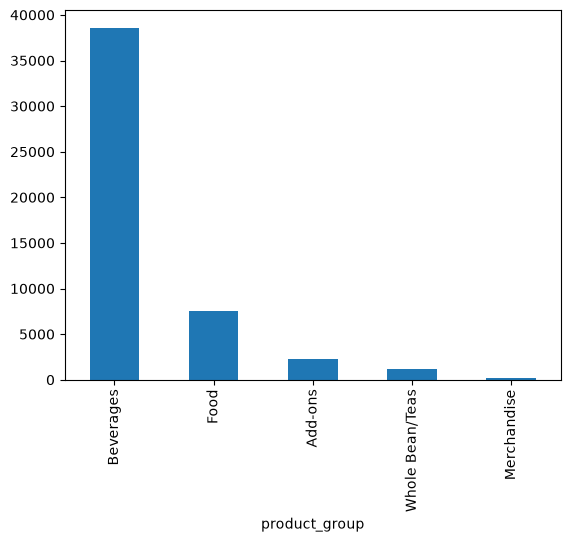

In [125]:
 cfe['product_group'].value_counts().plot(kind='bar');

##### 27.❓Can you calculate the median profit for each product type?

In [ ]:
cfe.groupby('product_type')['profit'].median()

##### 28.❓Create a column that shows the transaction_day



In [130]:
cfe['transaction_day'] = cfe['transaction_date'].dt.day


##### 29.❓Is there a relationship between the day of the week and the total sale revenue? How could you explain any relationship you can see in the data?
*hint*: total sale revenue is the line_item_amount column

In [136]:
cfe['day_of_week'] = pd.to_datetime(cfe['transaction_date']).dt.day_name()

cfe.groupby('day_of_week')['line_item_amount'].sum().sort_values(ascending=False)
#Monday, the first day of the working week, generates the highest revenue
#(Tuesday-Wednesday): Revenue is strong and stable 
# Weekend (Thursday-Sunday): Revenue gradually declines, reaching its lowest point on Sunday.
#The business relies heavily on weekday commuters rather than weekend shoppers.

day_of_week
Monday       39563.74
Wednesday    34374.03
Tuesday      32371.81
Friday       32304.55
Saturday     32138.85
Thursday     31902.82
Sunday       31014.75
Name: line_item_amount, dtype: float64

##### 30.❓Can you make a bar chart for the previous step?

_🎨 Visualize your results 🎨_

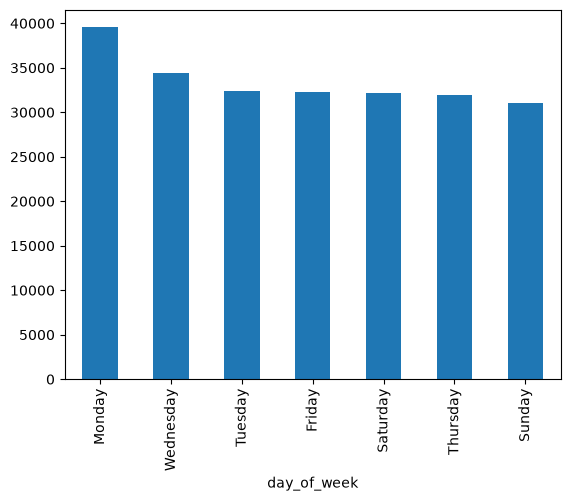

In [144]:
revenue = cfe.groupby('day_of_week')['line_item_amount'].sum().sort_values(ascending=False)
revenue.plot(kind ='bar');


##### Write your findings here please:
👉 More transactions on Monday suggest a "back to work blues" effect

##### 31.❓The client suspects that the Gen Z customer cohort spends the most. Can you test this out and confirm whether it's true or not?

In [147]:
def assign_generation(year):
    if (year >= 1950) and (year <= 1964):
        return 'Baby Boomers'
    elif 1965 <= year <= 1979:
         return 'Gen X'
    elif 1980 <= year <= 1989:
        return 'Older Millennials'
    elif 1990 <= year <= 1994:
        return 'Younger Millennials'
    elif 1995 <= year <= 2001:
        return 'Gen Z'
    else:
        return 'Other'

cfe['generation'] = cfe['customer_birth_year'].apply(assign_generation)

categroy_generation = cfe.groupby('generation')['line_item_amount'].sum().sort_values(ascending=False)

categroy_generation


generation
Other                  119337.82
Baby Boomers            27295.04
Gen X                   26739.61
Older Millennials       25166.90
Gen Z                   19716.40
Younger Millennials     15414.78
Name: line_item_amount, dtype: float64

##### 32.❓Prove previous step by plotting a bar chart

_🎨 Visualize your results 🎨_

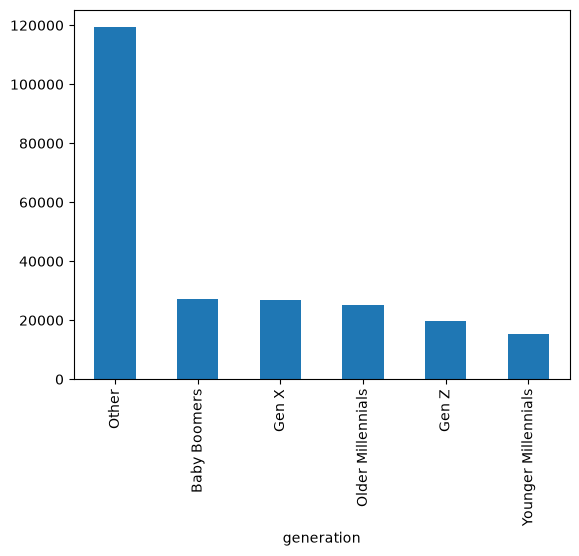

In [149]:
categroy_generation.plot(kind='bar');


##### 33.❓ Is GenZ spend the most as suspected? 
##### Write your findings here please:

👉 It looks like the opposite, Gen Z spend the second lowest in total.
-- -

## Part B 
In this section explore the coffee shop data to answer the following questions : 
1. **What kinds of products type generate the most profit? show top 5 only. Plot a chart to show the result**
2. **What segment of customers generate the most profit ratio? Plot a chart to show the result**


##### 1.❓What kinds of products type generate the most profit? show top 5 only


In [151]:
top5=cfe.groupby('product_type')['profit'].sum().sort_values(ascending=False).head(5)
top5


product_type
Barista Espresso         24510.50
Brewed Chai tea          19224.25
Gourmet brewed coffee    18944.72
Brewed Black tea         11950.33
Brewed herbal tea        11829.56
Name: profit, dtype: float64

##### 2.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

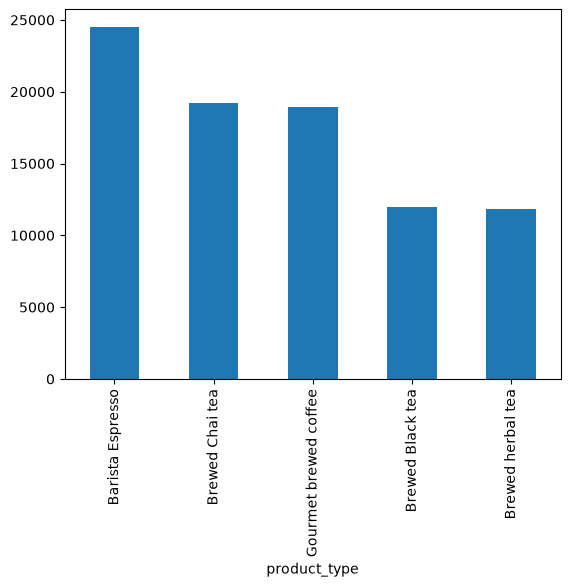

In [172]:
top5.plot(kind='bar');


##### 3.❓What segment of customers generate the most profit ratio? 

*Hint*: Show the average of profit ratio

In [209]:
cfe.groupby('generation')['profit_ratio'].mean().sort_values(ascending=False)


generation
Gen X                  0.337172
Gen Z                  0.334760
Older Millennials      0.334465
Other                  0.333890
Baby Boomers           0.333038
Younger Millennials    0.332600
Name: profit_ratio, dtype: float64

##### 4.❓Plot a chart to show the above result

_🎨 Visualize your results 🎨_

In [ ]:
plot = cfe.groupby('generation')['profit_ratio'].mean().sort_values(ascending=False)
plot.plot(kind = 'bar');



## Part C : Dig Deeper

In this section you are going to be doing your own analysis to answer this 3 main questions :
##### 1.❓Are there better or worse days/times in terms of sales? Plot a chart to show the result

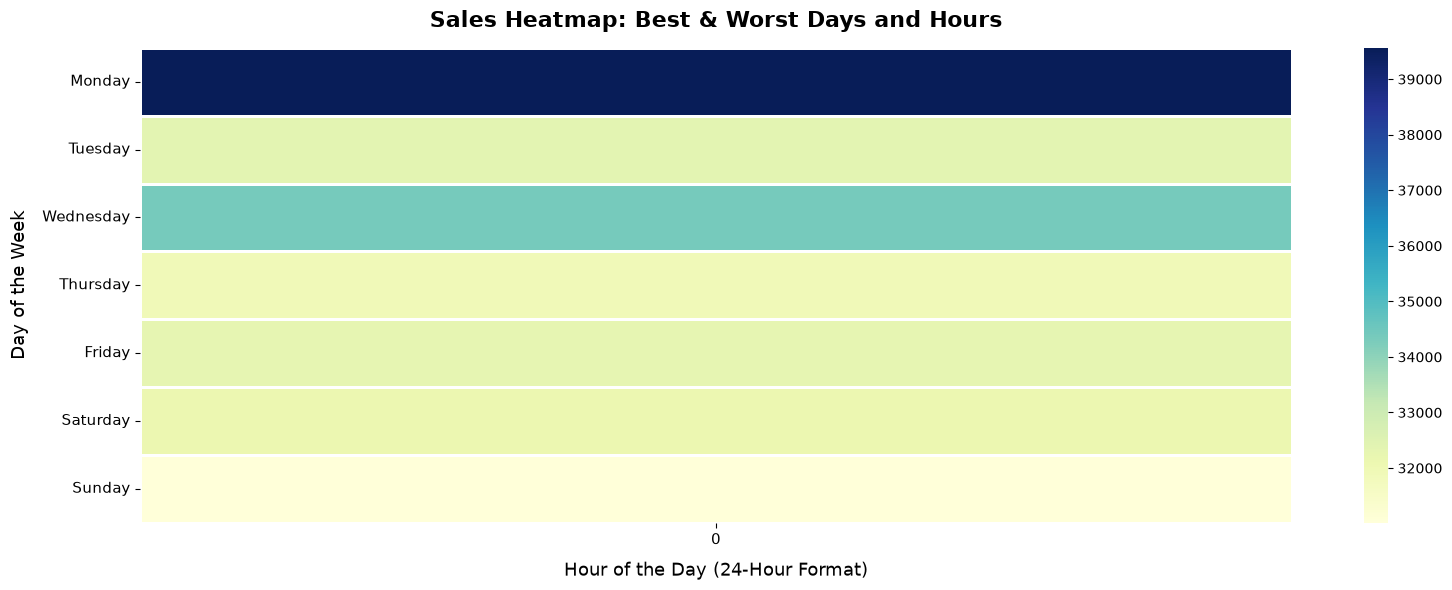

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap = heatmap.reindex(days_order)

plt.figure(figsize=(16, 6))
sns.heatmap(heatmap, cmap='YlGnBu', linewidths=0.8, cbar=True)

plt.title('Sales Heatmap: Best & Worst Days and Hours', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day (24-Hour Format)', fontsize=13, labelpad=10)
plt.ylabel('Day of the Week', fontsize=13, labelpad=10)

plt.xticks(rotation=0, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [196]:
# Creating time categories function to return Morning, Noon, Evenging, Night based on transaction_time


def assign_time_category(time_val):

    hour = pd.to_datetime(time_val).hour
    
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Noon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'


# use apply to apply the time category into a new column called time_category

cfe['time_category'] = cfe['transaction_time'].apply(assign_time_category)


0       Noon
1    Morning
2       Noon
3       Noon
4    Evening
Name: time_category, dtype: str

In [208]:
# Are there better or worse days/times in terms of sales?

# Write your findings

#Best days and Times is Mondays and Wednesdays, specifically during the Morning period 7AM to 10AM
#Worst days and Times is Weekendsin the Night period (after 9 PM) .

##### 2.❓Does customers’ willingness to pay for `Beverages` product group vary by generation? Plot a chart to show the result

C:\Users\Dell\AppData\Local\Temp\ipykernel_10932\2154020135.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gen_wtp.index, y=gen_wtp.values, palette='Blues_r')


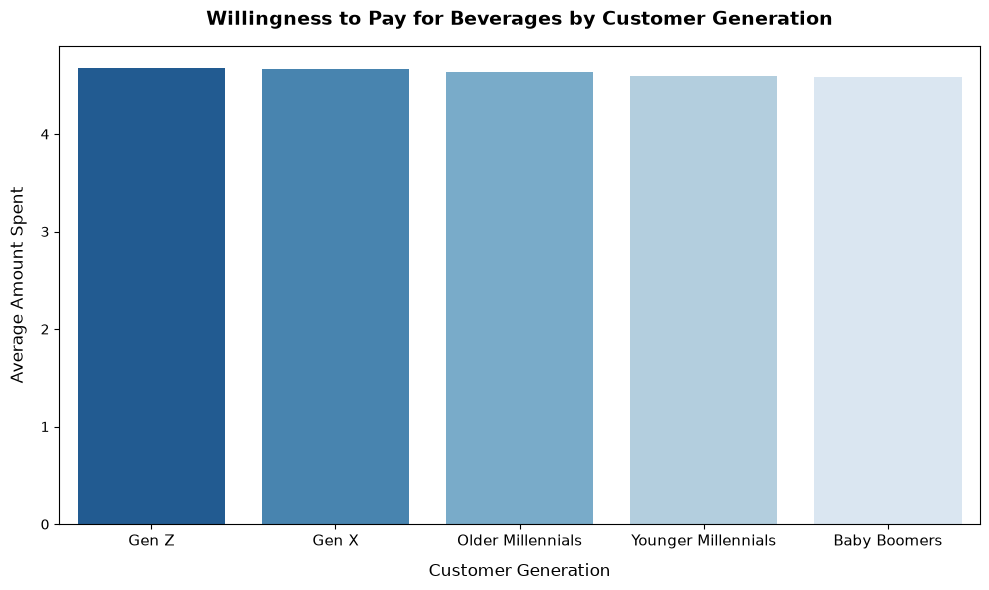

In [215]:
# Does customers’ willingness to pay for Beverages vary by generation?
import matplotlib.pyplot as plt
import seaborn as sns

beverages_df = cfe[cfe['product_group'].str.lower() == 'beverages']
gen_wtp = beverages_df.groupby('customer_generation')['line_item_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=gen_wtp.index, y=gen_wtp.values, palette='Blues_r')

plt.title("Willingness to Pay for Beverages by Customer Generation", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Customer Generation", fontsize=12, labelpad=10)
plt.ylabel("Average Amount Spent", fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

# Write your findings

##### 3.❓Do customers who have been customers longer tend to spend more? Plot a chart to show the result (Hint : You may need to use date.today() to get todays date)

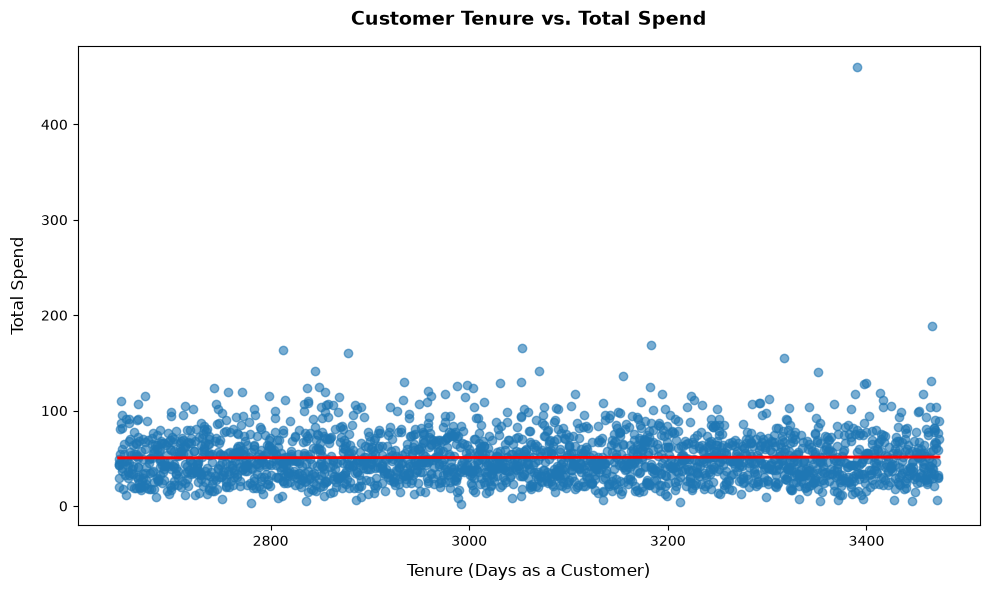

In [216]:

from datetime import date


customer_spend = cfe.groupby('customer_id').agg({
    'customer_since': 'first',
    'line_item_amount': 'sum'
}).reset_index()


customer_spend['customer_since'] = pd.to_datetime(customer_spend['customer_since'])
todays_date = pd.to_datetime(date.today())
customer_spend['tenure_days'] = (todays_date - customer_spend['customer_since']).dt.days


plt.figure(figsize=(10, 6))
sns.regplot(
    data=customer_spend, 
    x='tenure_days', 
    y='line_item_amount', 
    scatter_kws={'alpha': 0.6, 'color': '#1f77b4'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Customer Tenure vs. Total Spend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenure (Days as a Customer)', fontsize=12, labelpad=10)
plt.ylabel('Total Spend', fontsize=12, labelpad=10)

plt.tight_layout()
plt.savefig('customer_tenure_vs_spend.png', bbox_inches='tight')
